In [1]:
import pickle
import pandas as pd
import shap


In [3]:
ridge_model = pickle.load(open('data/ridge_model_smote.pkl', 'rb'))
test_file="data/RNAseq_Combat_z_score_Test_set.csv"
annot = pd.read_pickle("data/annot.pkl")
selected_genes_file = "data/selected_genes.txt"
with open(selected_genes_file, "r") as file:
    symbol_names = file.read().splitlines()


/home/karen/Documents/GitHub/shinny/.venv/lib/python3.11/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator Ridge from version 1.4.1.post1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [4]:
test_data = pd.read_csv(test_file)


In [17]:
sample_data = test_data[test_data.columns[-5:]]
sample_data.to_csv("data/test_sample_data.csv", index=False)

In [20]:
sample_data

,Age,Status,Experiment,Sample,Sex
0,24.0,Healthy,GSE157585,SRR12604218,0
1,18.0,Healthy,GSE167186,SRR13759023,0
2,23.0,Healthy,GSE167186,SRR13759025,0
3,26.4,untrained,GSE60590,SRR1555206,female
4,71.0,Healthy,GSE157585,SRR12604184,0
...,...,...,...,...,...
103,71.0,Healthy,GSE157585,SRR12604112,0
104,23.0,Healthy,GSE167186,SRR13759011,0
105,72.0,Healthy,GSE164471,SRR13388749,male
106,71.0,Healthy,GSE157585,SRR12604127,0


In [5]:
test_data = test_data.fillna(0)

In [6]:
test_data.drop(columns=["Age.1"], inplace=True)
X_test_data = test_data[test_data.columns[:-5]]
z_test_data = test_data[test_data.columns[-4:]]
y_test_data = test_data["Age"]
z_test_data = z_test_data["Experiment"]

In [14]:
z_test_data

0      GSE157585
1      GSE167186
2      GSE167186
3       GSE60590
4      GSE157585
         ...    
103    GSE157585
104    GSE167186
105    GSE164471
106    GSE157585
107    GSE167186
Name: Experiment, Length: 108, dtype: object

In [7]:
explainer = shap.Explainer(ridge_model, X_test_data)
shap_values = explainer(X_test_data)

In [11]:
type(shap_values)

shap._explanation.Explanation

In [13]:
# save shap_values to pickle file
with open('data/shap_values_ridge.pkl', 'wb') as f:
    pickle.dump(shap_values, f)

Sample 0/ 108 
 Age: 24.0 
 Experiment: GSE157585


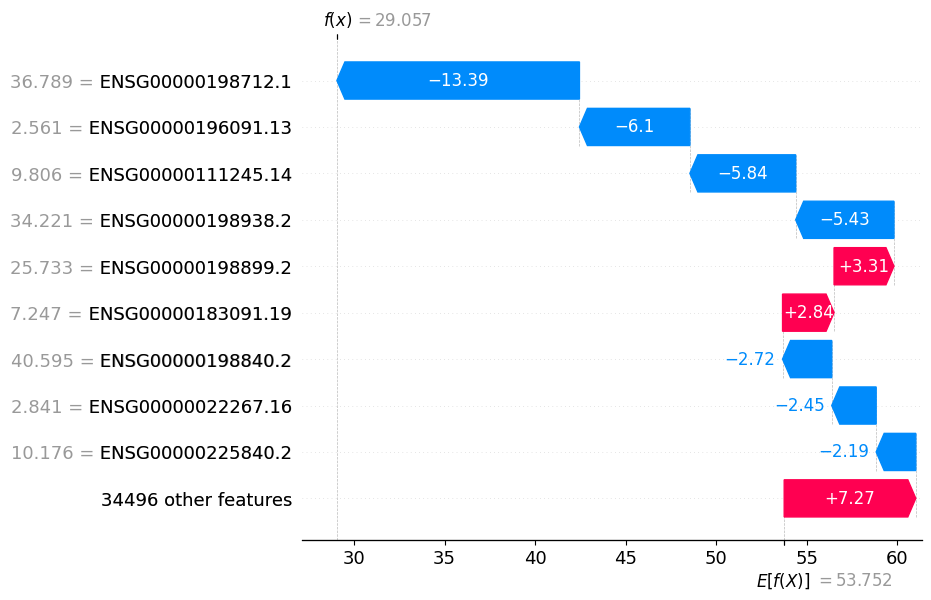

In [18]:
index=0
title = f"Sample {index}/ {len(shap_values)} \n Age: {y_test_data[index]} \n Experiment: {z_test_data[index]}"
print(title)
shap.plots.waterfall(shap_values[index])

.values =
array([ 8.45164378e-05,  1.07339108e-04, -2.36547839e-04, ...,
        1.25320832e-04, -6.50231853e-06,  1.28053492e-04])

.base_values =
np.float64(53.75167188820227)

.data =
array([-0.02223277, -0.02444608, -0.00621633, ..., -0.0245264 ,
       -0.02319945, -0.02443183])

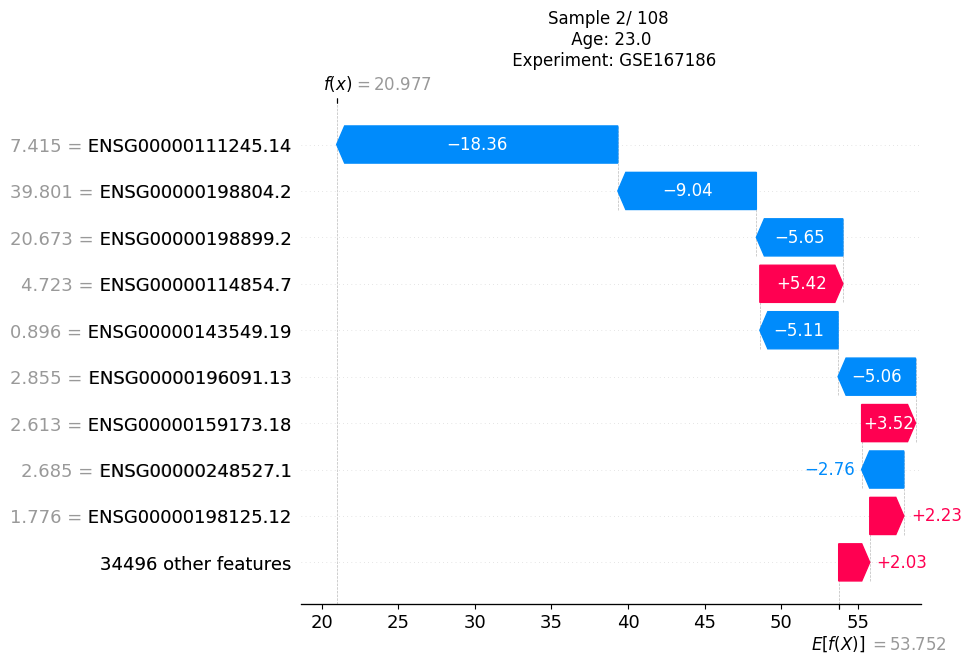

In [9]:
import matplotlib.pyplot as plt


# Create the SHAP waterfall plot
fig = shap.plots.waterfall(shap_values[index], show=False)

# Save the figure
plt.title(title)
plt.savefig(f"shap_waterfall_Ridge_sample_{index}.png", dpi=300, bbox_inches="tight")

# Show the plot
plt.show()